In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os, sys
import ast

# Get the absolute path to the src directory
src_path = os.path.abspath(os.path.join(os.getcwd(), "../"))
# Add src_path to the system path
sys.path.insert(0, src_path)
from utils import mappings

PUBLICATIONS_PATH = "../../data/raw/publication_meta/br_publication_meta.csv"
AUTHORS_PATH = "../../data/processed/6_authors.csv"

In [2]:
def create_interdisciplinary_heatmap(df, authors_df, normalize=True):
    """
    Creates a normalized heatmap showing interdisciplinary collaborations between subfields.
    
    Args:
        df (DataFrame): Publication metadata
        authors_df (DataFrame): Author information with primary subfields
        normalize (bool): Whether to normalize by total publications in each subfield
        
    Returns:
        matplotlib.figure.Figure: The created figure
    """
    # Create mappings
    author_subfield_map = authors_df.set_index('id')['primary_subfield'].to_dict()
    
    # Prepare publication data with original names
    df = df.copy()
    df['subfield'] = df['subfield'].apply(
        lambda x: ast.literal_eval(x)['display_name']
    )
    subfield_counts = df['subfield'].value_counts()
    df['authorships'] = df['authorships'].apply(
        lambda x: [a['id'] for a in ast.literal_eval(x)]
    )
    
    # Initialize collaboration matrix with original names
    all_subfields = sorted(list(
        set(authors_df['primary_subfield'].dropna()) |
        set(df['subfield'])
    ))
    collaboration_matrix = pd.DataFrame(0, index=all_subfields, columns=all_subfields)
    
    # Populate matrix with original names
    for _, row in df.iterrows():
        pub_subfield = row['subfield']
        author_subfields = {author_subfield_map.get(aid) for aid in row['authorships']}
        author_subfields.discard(pub_subfield)  # Remove self-collaborations
        author_subfields.discard(None)  # Remove unknown subfields
        for subfield in author_subfields:
            if subfield in collaboration_matrix.index:
                collaboration_matrix.loc[subfield, pub_subfield] += 1
    
    # Transpose the matrix to switch axes
    collaboration_matrix = collaboration_matrix.T
    
    # Normalize using original names
    if normalize:
        collaboration_matrix = (collaboration_matrix / subfield_counts * 100).fillna(0)
        fmt = '.1f'
        cbar_label = '% of Publications with Cross-Subfield Authors'
    else:
        fmt = 'd'
        cbar_label = 'Count of Cross-Subfield Collaborations'
    
    # Create display version with shortened names
    display_matrix = collaboration_matrix.copy()
    display_matrix.index = display_matrix.index.map(
        lambda x: mappings.SUBFIELDS_SHORT.get(x, x)
    )
    display_matrix.columns = display_matrix.columns.map(
        lambda x: mappings.SUBFIELDS_SHORT.get(x, x)
    )
    
    # Set theme to match the standard notebook
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.5)
    
    # Create the heatmap visualization
    plt.figure(figsize=(10, 8))
    fig = sns.heatmap(
        display_matrix,
        annot=True,
        fmt=fmt,
        cmap="Blues",
        linewidths=0.5,
        cbar_kws={"label": cbar_label},
        vmin=0,
        vmax=30 if normalize else None,
    )
    
    plt.xlabel("Author Primary Subfield", fontsize=12)  # Swapped
    plt.ylabel("Publication Subfield", fontsize=12)     # Swapped
    plt.xticks(rotation=90, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig("../../results/figures/subfields_collabs_heatmap.pdf", format="pdf")
    
    return fig

In [3]:
publications_df = pd.read_csv(PUBLICATIONS_PATH)
authors_df = pd.read_csv(AUTHORS_PATH)

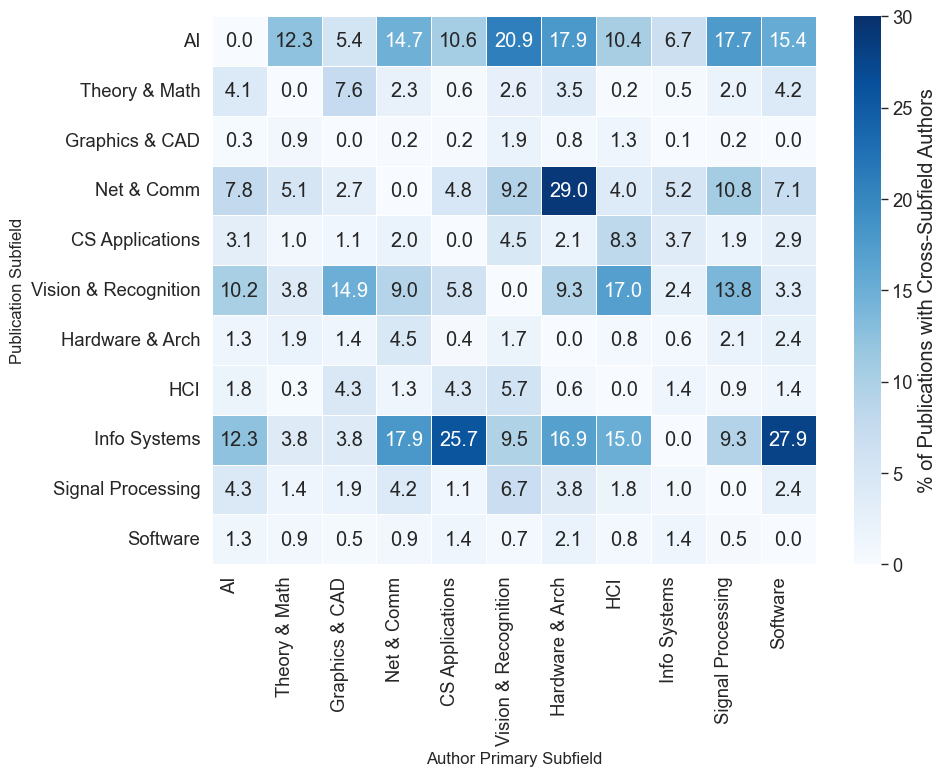

In [4]:
fig = create_interdisciplinary_heatmap(publications_df, authors_df)
plt.show()